In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")
sns.set_palette("Set2")

In [2]:
path= 'credit_risk_dataset.csv'
df= pd.read_csv(path)

In [3]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


### EDA

In [5]:
#Questions to answer:
# what are we studying
# how was our data collected
# where, when
# what is the target variable
# based on prior knowledge what features we think influence Y the most, lets explore them.
# outliers / nan values (what do they represent, can they be fixed / ignored)

In [6]:
#1 we are studying unsecured credit loans and their default rate
# to make better decision about credit loan grants in the future.
#2 it appears our data is collected through omitting the person's name & id
# and simply stack the loans that were granted on top of each other, (we'll try to fix that by adding id later)
#3 where and when is not disclosed here
#4 target variable is the loan_status (0 - 1)
#5 All are interesting .

In [7]:
# questions about features influence on y:
# are young people / low income people likely to default ?
# > is that person's a freshman at a company (low p.e.l) and is expected to generate higher incomes
# does the home_ownership status affect the loan_status
# does loan_grade have anything to do with defaults, and are whats the mean age for those with low grade
# does loan_int_rate affect the loan_status or broadly the (l.p.e)
# does the person's default_history affect the loan_status
# does the person's credit_history affect the loan, are youngsters related ?
# loan_amount and its relation with intent and the age/income.
# do we need an indicator 

In [8]:
#checking for duplicated lines
print('Duplicated lines:', len(df[df.duplicated()]))
#fixing that:
df= df[~df.duplicated()]
df.reset_index(drop= True, inplace= True)

Duplicated lines: 165


In [9]:
df[df.duplicated(subset= ['person_age','person_income','person_home_ownership',
                       'person_emp_length','cb_person_default_on_file',
                       'cb_person_cred_hist_length'], keep= False)].shape
# 5835 duplicated lines, means more than one person took multiple loans at once.

(5835, 12)

In [10]:
cols= ['person_age','person_income','person_home_ownership',
                       'person_emp_length','cb_person_default_on_file',
                       'cb_person_cred_hist_length']
df['id']= df.groupby(cols, dropna= False).ngroup()
df['count'] = df.groupby('id', dropna= False)['id'].transform('count')

In [11]:
len(df['id'].unique()) #appears there are 29031 unique people recorded taking loans

29031

In [12]:
colors= ['#4d5359','#fa6d76', '#fafafb', '#fca8ad', '#a3a9af', '#fecacb', '#fb888f', '#fa5560']

In [13]:
# imbalanced data-set 'we're interested in those that defaulted generally
df['loan_status'].value_counts(normalize= True) \
    .mul(100).round(1) \
    .astype('str').add(' %')

loan_status
0    78.1 %
1    21.9 %
Name: proportion, dtype: object

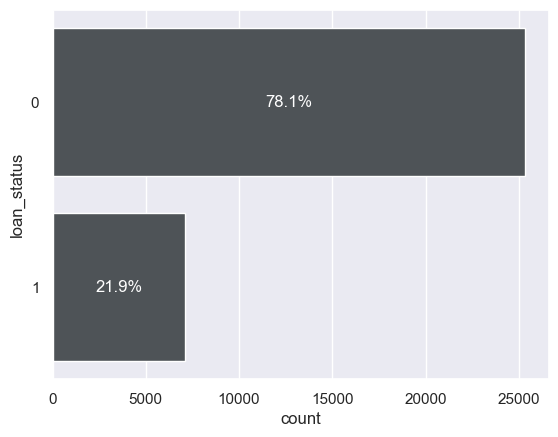

In [14]:
plt.figure()
sns.countplot(data= df, y= 'loan_status', color= colors[0])
plt.bar_label(plt.gca().containers[0], 
             labels=df['loan_status'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%',
             label_type='center', color='white')
plt.show()

In [47]:
# questions about features influence on y:
# are young people / low income people likely to default ?
# > is that person's a freshman at a company (low p.e.l) and is expected to generate higher incomes
# does the home_ownership status affect the loan_status
# does loan_grade have anything to do with defaults, and are whats the mean age for those with low grade
# does loan_int_rate affect the loan_status or broadly the (l.p.e)
# does the person's default_history affect the loan_status
# does the person's credit_history affect the loan, are youngsters related ?
# loan_amount and its relation with intent and the age/income.
# do we need an indicator 

<Figure size 640x480 with 0 Axes>

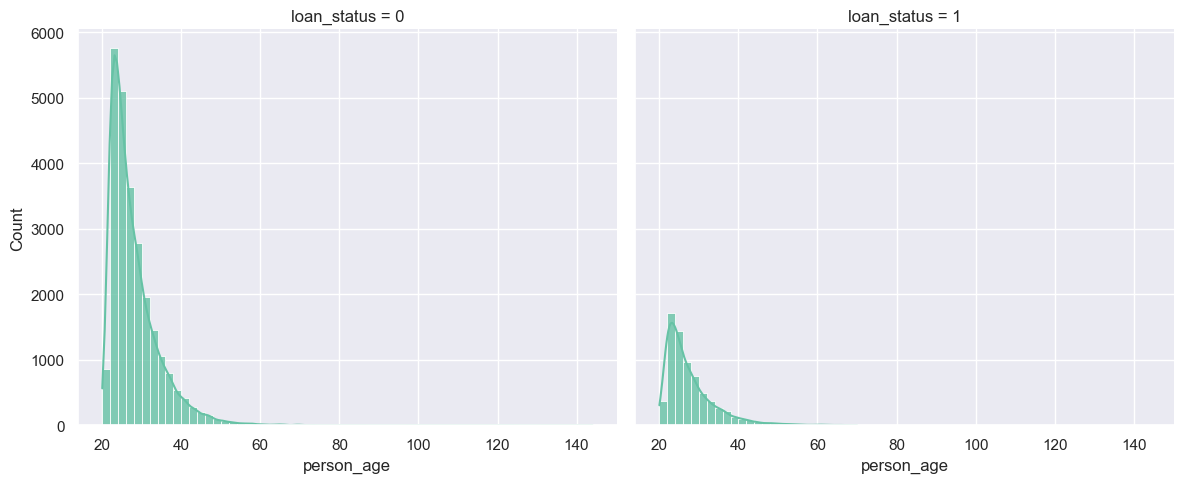

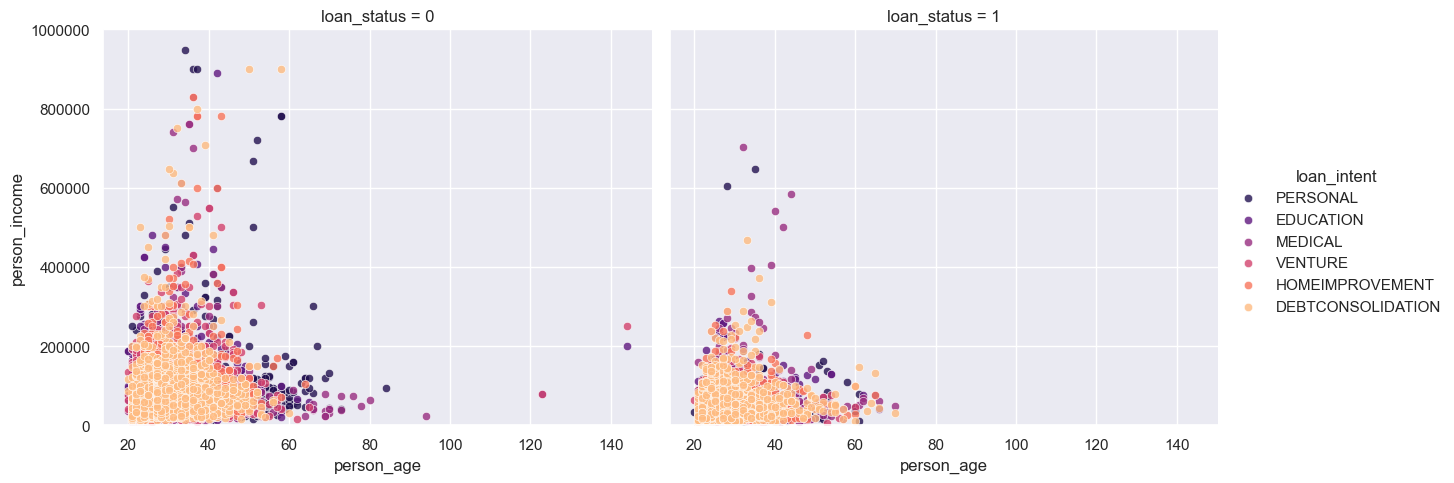

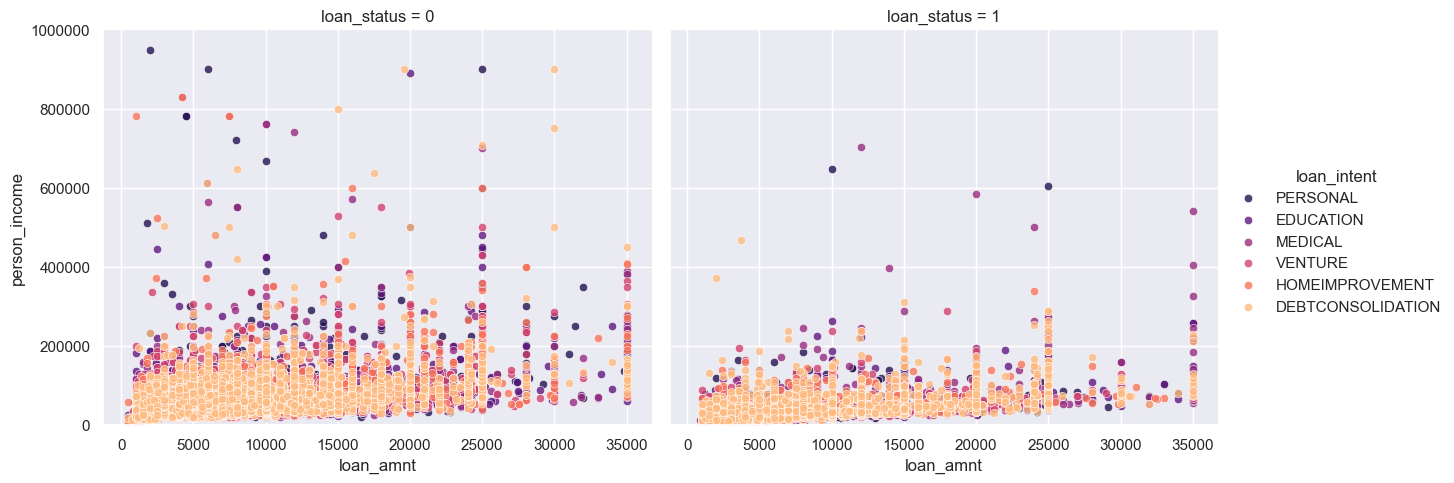

In [16]:
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, palette= 'Dark2')
q.map(sns.histplot, 'person_age', binwidth= 2, kde= True, alpha= .8)
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, hue= 'loan_intent', palette= 'magma')
q.map(sns.scatterplot, 'person_age', 'person_income', alpha= .8)
q.add_legend()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 1000000))
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, hue= 'loan_intent', palette= 'magma')
q.map(sns.scatterplot,'loan_amnt', 'person_income', alpha= .8)
q.add_legend()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 1000000))
plt.show()
# are young people / low income people likely to default ?
# not really people of all ages do default, but there is a clear insight about the income
# those with higher income default less regardless of age.
# outliers appear, we'll deal with them later in preprocessing step (4 loans so far)
# it appears most of those that do default are below 40 yr old, interesting

<Figure size 640x480 with 0 Axes>

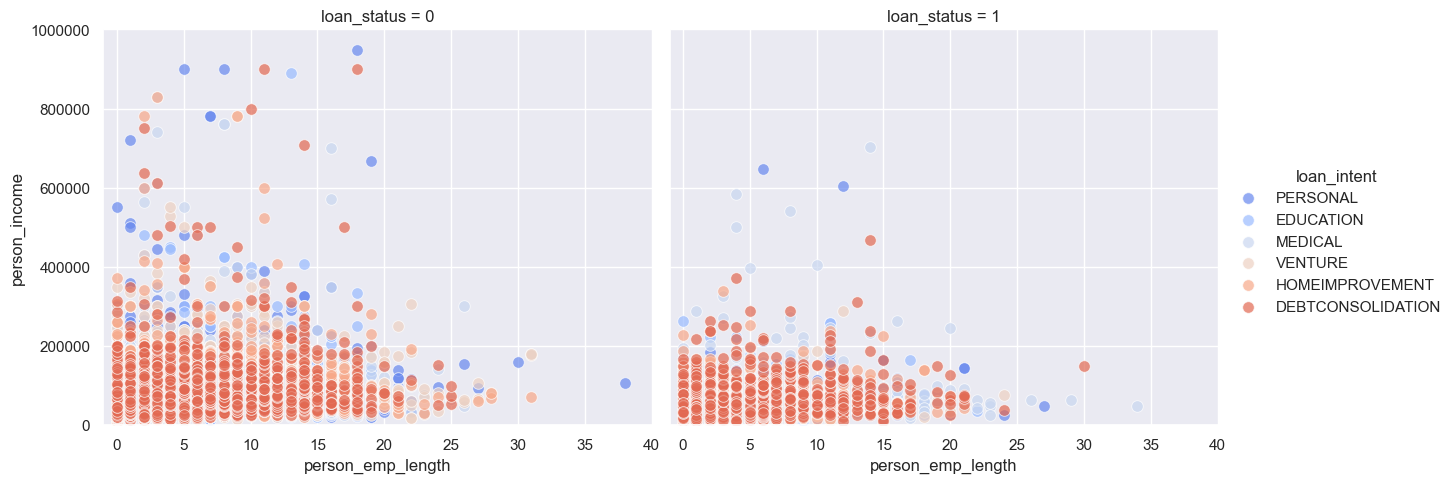

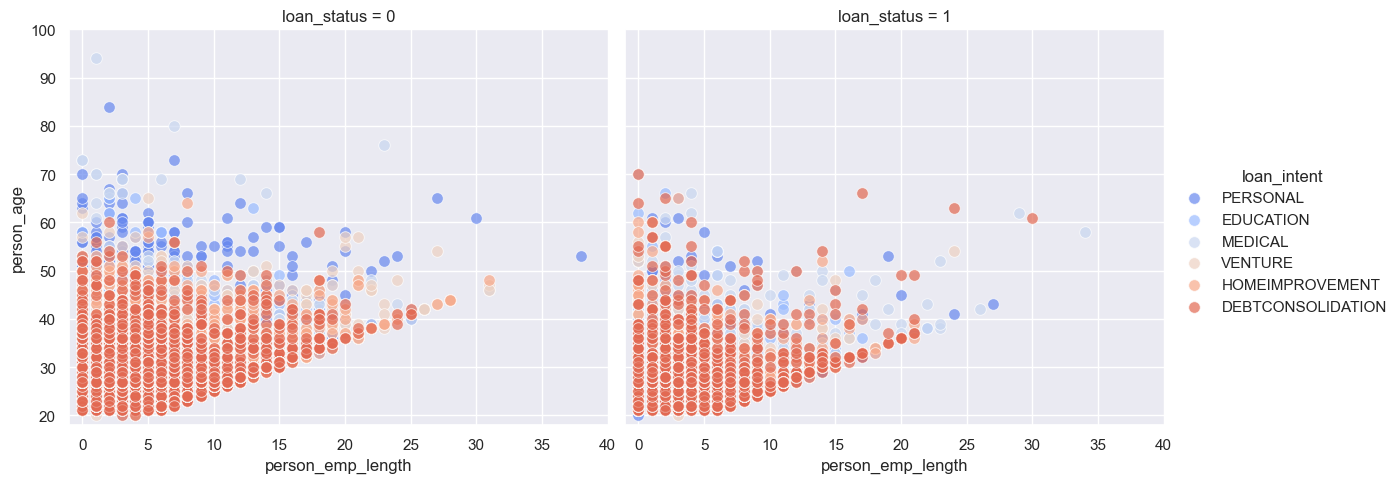

In [17]:
# > is that person's a freshman at a company (low p.e.l) and is expected to generate higher incomes
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', hue='loan_intent', palette= 'coolwarm', height= 5, aspect= 1.2)
q.map(sns.scatterplot, 'person_emp_length', 'person_income', alpha= .7,s= 70)
q.add_legend()
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 1000000))
plt.xlim((-1,40))
q= sns.FacetGrid(data= df, col= 'loan_status', hue='loan_intent', palette= 'coolwarm', height= 5, aspect= 1.2)
q.map(sns.scatterplot, 'person_emp_length', 'person_age', alpha= .7,s= 70)
plt.ylim((18, 100))
plt.xlim((-1,40))
q.add_legend()
plt.show()
# there is no clear trend about freshman defaulting, although we see a coned-like shape 
# showing a linear relationship between age and (p.e.l) which is expected

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 640x480 with 0 Axes>

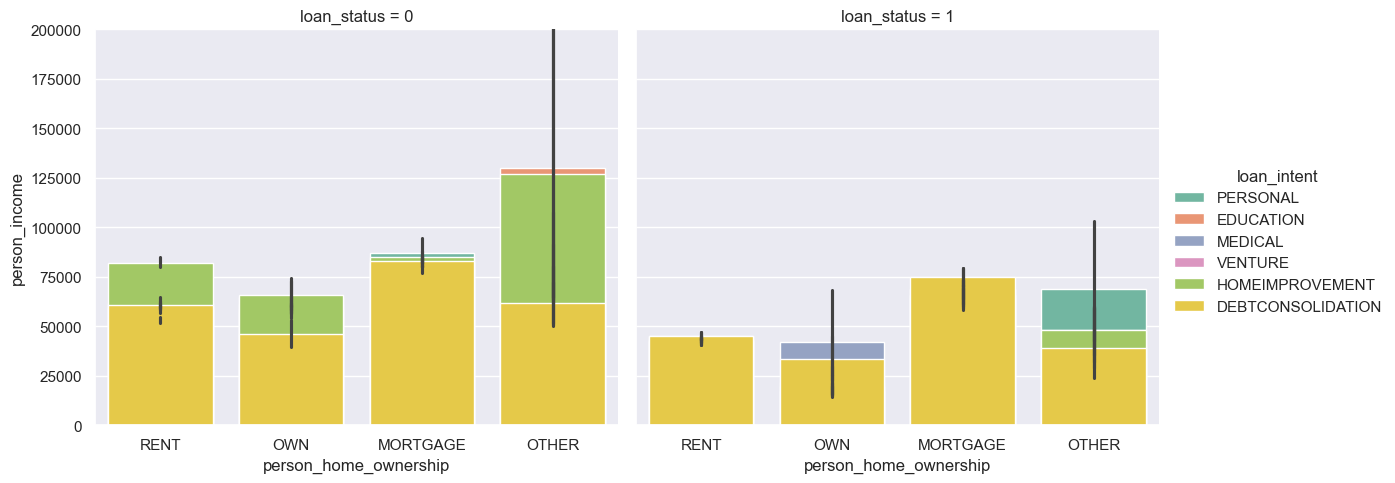

In [25]:
# > what is their financial situation do they rent or own a house
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, hue= 'loan_intent')
q.map(sns.barplot, 'person_home_ownership', 'person_income')
plt.ticklabel_format(style='plain', axis='y')
plt.ylim((0, 200000))
q.add_legend()
plt.show()
#there is a very strong correlation between low wages / rental or mortgage status with loan default
# We could certainly feature engineer a (home_owner) column, we'll do that later

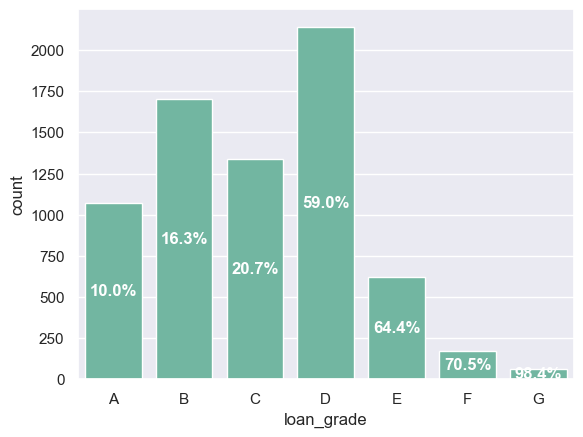

In [37]:
# does loan_grade have anything to do with defaults,
grade_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']

# 1. Calculate the percentage (mean of loan_status) for each grade
# This is the "Defaults / Total" ratio you requested
percentages = df.groupby('loan_grade')['loan_status'].mean().reindex(grade_order) * 100

# 2. Plot the raw counts of defaults
plt.figure()
ax = sns.countplot(data=df[df['loan_status'] == 1], x='loan_grade', order=grade_order)

# 3. Create string labels (e.g., "50.0%")
pct_labels = [f'{p:.1f}%' for p in percentages]

# 4. Map the labels to the bars
ax.bar_label(ax.containers[0], labels=pct_labels, label_type='center', color='white', weight='bold')
plt.show()
# it appears that loans D/E/F show higher chances of defaulting (percentage sign is their frequency)
# ie their presence in the default status

In [ ]:
mask= df['loan_grade'].isin(['D','E','F','G'])
df[mask]['person_age'].describe().round(1)
# strong correlation between bad grade loans and young people (26 yr median)
# could be because they have bad reputation

count    4895.0
mean       27.9
std         6.4
min        20.0
25%        23.0
50%        26.0
75%        30.0
max        70.0
Name: person_age, dtype: float64

<Figure size 640x480 with 0 Axes>

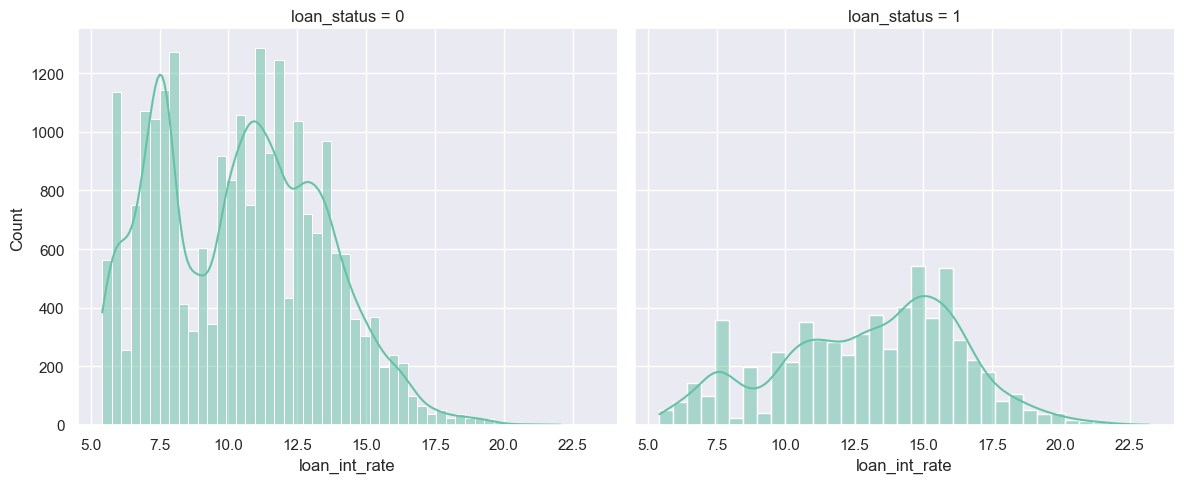

Loan_int_rate Median for defaulted loans: 13.49


In [56]:
# does loan_int_rate affect the loan_status or broadly the (l.p.e)
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', palette= 'Dark2', height= 5,aspect= 1.2)
q.map(sns.histplot, 'loan_int_rate', kde= True)
plt.show()
# Strong correlation that defaulted loan's interest rate cluster in a normal-like shape
print('Loan_int_rate Median for defaulted loans:',df[df['loan_status'] == 1]['loan_int_rate'].median())

In [57]:
# does the person's default_history affect the loan_status
# does the person's credit_history affect the loan, are youngsters related ?
# loan_amount and its relation with intent and the age/income.
# do we need an indicator 

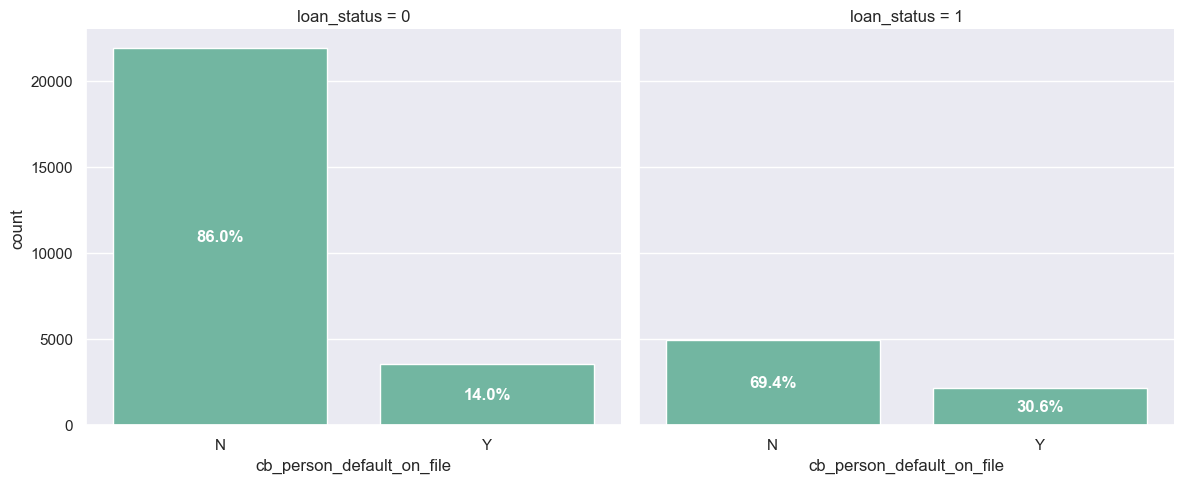

In [66]:
# does the person's default_history affect the loan_status
q = sns.FacetGrid(data=df, col='loan_status', height=5, aspect=1.2)
q.map(sns.countplot, 'cb_person_default_on_file', order=['N', 'Y'])

for ax in q.axes.flat:
    # 1. Calculate the total count for this specific subplot
    total = sum([p.get_height() for p in ax.patches])
    
    # 2. Create labels as a percentage of that total
    labels = [f'{(p.get_height()/total)*100:.1f}%' for p in ax.patches]
    
    # 3. Apply labels
    ax.bar_label(ax.containers[0], labels=labels, label_type='center', color='white', weight='bold')

plt.show()
# it appears that person's default history doesn't give us strong evidence that the person will not
# default, as we see nearly 70% of those that defaulted had clear history of defaults

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\seaborn\axisgrid.py:718: UserWarning: Using the countplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


<Figure size 640x480 with 0 Axes>

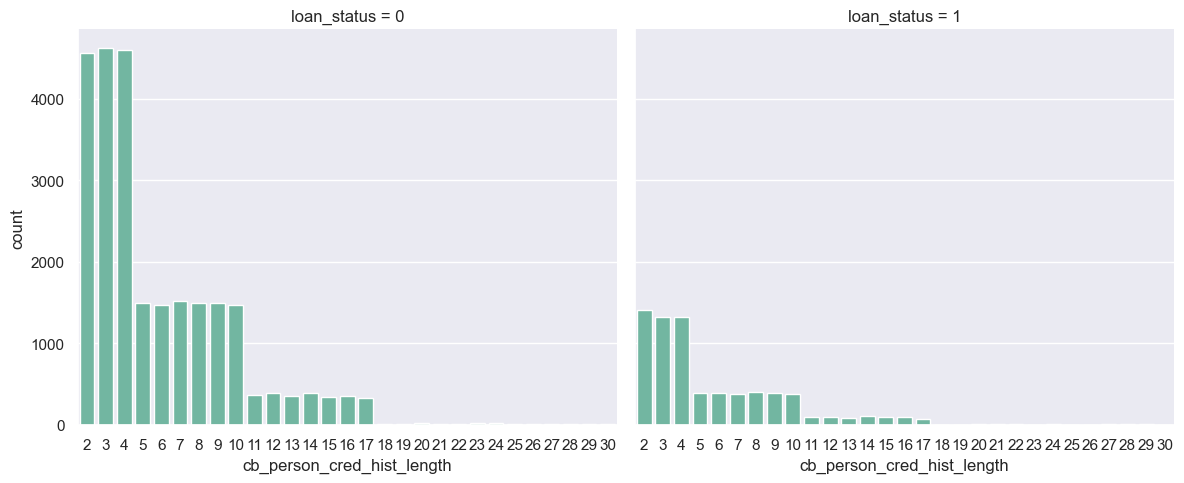

In [71]:
# does the person's credit_history affect the loan, are youngsters related ?
plt.figure()
q= sns.FacetGrid(data= df, col= 'loan_status', height= 5, aspect= 1.2, palette= 'Dark2')
q.map(sns.countplot, 'cb_person_cred_hist_length')
plt.show()

In [19]:
df[df['loan_status'] == 1]['person_income'].describe().round(1)

count      7089.0
mean      49094.5
std       36342.4
min        4000.0
25%       30000.0
50%       41682.0
75%       59600.0
max      703800.0
Name: person_income, dtype: float64

In [20]:
# we see many Loans related to Debt consolidated are being defaulted